# Analisi della Pipeline MLOps in Movimento – PENTION-M

In questo notebook analizziamo le prestazioni operative della pipeline MLOps in movimento:

- Latenza end-to-end vista dal client (`e2e_latency_ms`)
- Latenza interna misurata dal servizio di monitoring (`svc_latency_ms`)
- Drift score fisico basato sul monitoraggio PIML (`drift_score`)
- Stabilità del modello e versione (`model_version`)
- Correlazione tra drift, latenza e confidenza del classificatore NPS
- Collegamento con i log di monitoring (`/logs/monitoring_log.jsonl`)

I dati provengono dallo script:

```text
validation/MLOps/mlops_pipeline_stress_test.py
che ha eseguito N simulazioni consecutive verso il servizio mlops_ingestion.

### Import e configurazione

In [1]:
import os
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Configurazioni grafiche di base
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
RESULTS_CSV = os.path.join(ROOT_DIR, "validation", "MLOps", "mlops_stress_results.csv")
MONITORING_LOG = os.path.join(ROOT_DIR, "logs", "monitoring_log.jsonl")

RESULTS_CSV, MONITORING_LOG


('c:\\Users\\marco\\Desktop\\Marco\\Universita\\Magistrale\\Traineeship\\Progetto\\Pention-System\\validation\\MLOps\\mlops_stress_results.csv',
 'c:\\Users\\marco\\Desktop\\Marco\\Universita\\Magistrale\\Traineeship\\Progetto\\Pention-System\\logs\\monitoring_log.jsonl')

### Caricamento dei risultati dello stress test

In [2]:
# Carica risultati dallo stress test
df = pd.read_csv(RESULTS_CSV)

print("Numero di run:", len(df))
df.head()


Numero di run: 20


,run_id,simulation_id,t_start_iso,e2e_latency_ms,svc_latency_ms,drift_score,mse_free,stability_index,confidence,model_version,...,mlops_monitoring_cpu,mlops_monitoring_mem,gaussian_dispersion_model_cpu,gaussian_dispersion_model_mem,correction_dispersion_piml_cpu,correction_dispersion_piml_mem,loc_emission_source_piml_cpu,loc_emission_source_piml_mem,clas_nps_cpu,clas_nps_mem
0,1,STRESS_20251125_200341_001,2025-11-25T20:03:44.474758Z,5228.41,19.71,0.0,NaN,4.0,0.782210,PIML_v1643,...,0.13,0.23,0.19,0.70,0.17,1.62,0.17,0.89,0.17,3.67
1,2,STRESS_20251125_200349_002,2025-11-25T20:03:52.276152Z,4828.58,12.17,0.0,NaN,4.0,0.892544,PIML_v1644,...,0.10,0.23,0.17,0.70,0.21,4.39,0.13,0.90,0.15,3.68
2,3,STRESS_20251125_200357_003,2025-11-25T20:03:59.675731Z,4774.12,9.89,0.0,NaN,4.0,0.968576,PIML_v1645,...,0.12,0.23,0.16,0.70,0.18,4.42,0.17,0.90,0.15,3.68
3,4,STRESS_20251125_200404_004,2025-11-25T20:04:07.028270Z,4971.60,9.84,0.0,NaN,4.0,0.925555,PIML_v1645,...,0.16,0.23,0.17,0.69,0.19,4.63,0.15,0.90,0.16,3.68
4,5,STRESS_20251125_200411_005,2025-11-25T20:04:14.565193Z,4721.48,12.62,0.0,NaN,4.0,0.344613,PIML_v1646,...,0.15,0.23,0.16,0.70,0.21,5.23,0.16,0.90,0.15,3.68


### Pulizia base e overview

In [3]:
# Conversione di alcune colonne numeriche
for col in ["e2e_latency_ms", "svc_latency_ms", "drift_score", "stability_index", "confidence"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Filtriamo solo le chiamate andate a buon fine
df_ok = df[df["http_status"] == 200].copy()

print("Run totali:", len(df))
print("Run con http_status == 200:", len(df_ok))

df_ok.describe()[["e2e_latency_ms", "svc_latency_ms", "drift_score", "confidence"]]


Run totali: 20
Run con http_status == 200: 20


,e2e_latency_ms,svc_latency_ms,drift_score,confidence
count,20.00000,20.000000,20.0,20.000000
mean,4850.06150,12.342000,0.0,0.784308
std,140.64249,2.586226,0.0,0.204093
min,4556.39000,9.840000,0.0,0.340566
25%,4762.78000,10.457500,0.0,0.693459
50%,4831.74000,11.590000,0.0,0.844201
75%,4909.64250,12.932500,0.0,0.955523
max,5228.41000,19.710000,0.0,0.971739


### Boxplot delle latenze

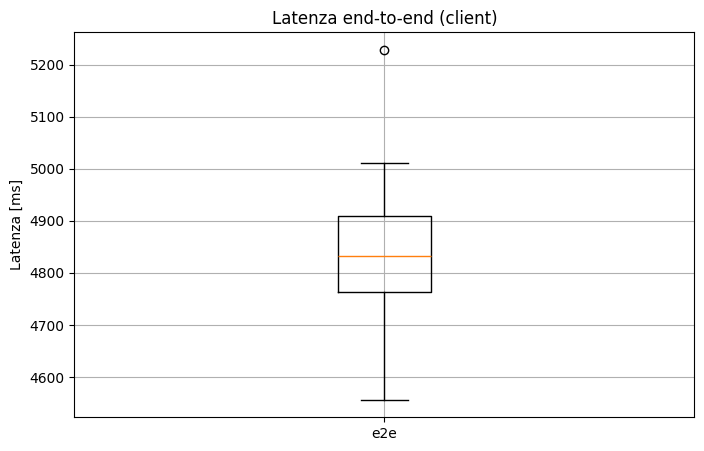

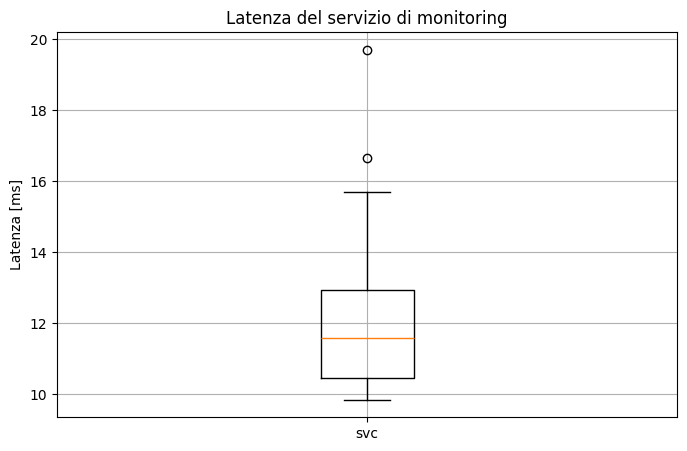

In [4]:
### Boxplot della latenza end-to-end
fig, ax = plt.subplots()
ax.boxplot(df_ok["e2e_latency_ms"].dropna(), tick_labels=["e2e"])
ax.set_ylabel("Latenza [ms]")
ax.set_title("Latenza end-to-end (client)")
plt.show()

### Boxplot della latenza del monitoring
fig, ax = plt.subplots()
ax.boxplot(df_ok["svc_latency_ms"].dropna(), tick_labels=["svc"])
ax.set_ylabel("Latenza [ms]")
ax.set_title("Latenza del servizio di monitoring")
plt.show()


### Latenza e drift nel tempo (per run)

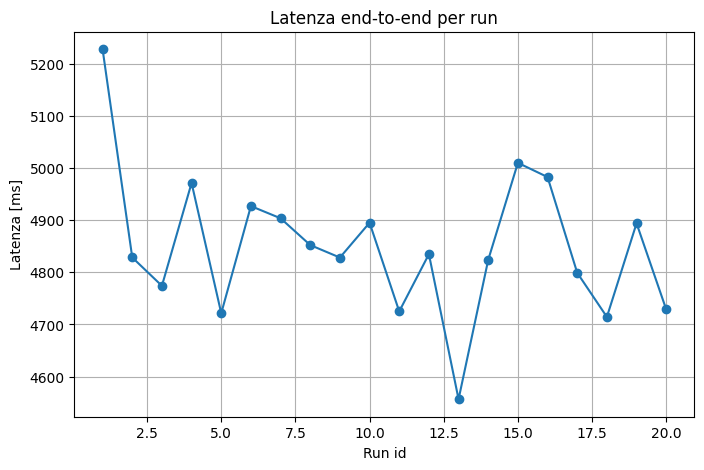

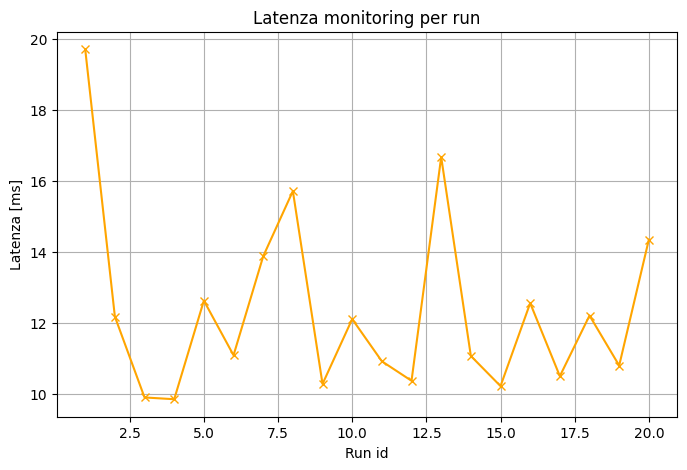

In [5]:
if "run_id" in df_ok.columns:
    x = df_ok["run_id"]

    ### Andamento latenza end-to-end
    plt.plot(df_ok["run_id"], df_ok["e2e_latency_ms"], marker="o")
    plt.xlabel("Run id")
    plt.ylabel("Latenza [ms]")
    plt.title("Latenza end-to-end per run")
    plt.grid(True)
    plt.show()

    ### Andamento latenza monitoring
    plt.plot(df_ok["run_id"], df_ok["svc_latency_ms"], marker="x", color="orange")
    plt.xlabel("Run id")
    plt.ylabel("Latenza [ms]")
    plt.title("Latenza monitoring per run")
    plt.grid(True)
    plt.show()


### Correlazione tra drift, latenza e confidenza

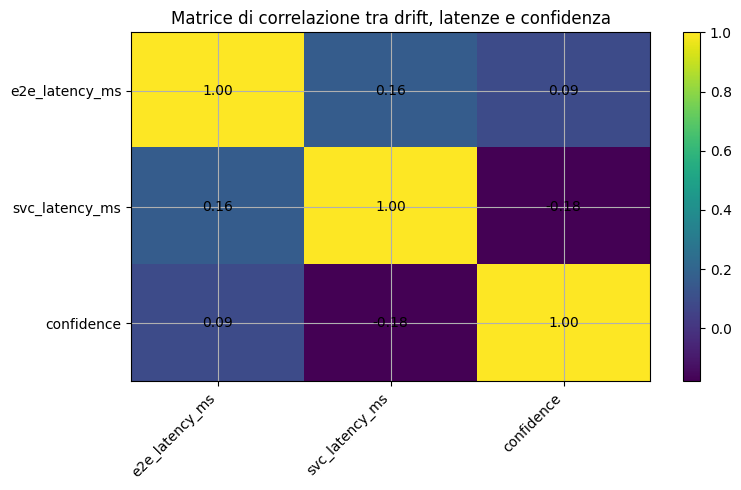

In [6]:
cols_for_corr = []

for col in ["e2e_latency_ms", "svc_latency_ms", "confidence"]:
    if col in df_ok.columns:
        cols_for_corr.append(col)

df_corr = df_ok[cols_for_corr].dropna()

if len(cols_for_corr) >= 2 and not df_corr.empty:
    corr = df_corr.corr()

    fig, ax = plt.subplots()
    im = ax.imshow(corr.values, aspect="auto")

    ax.set_xticks(range(len(cols_for_corr)))
    ax.set_yticks(range(len(cols_for_corr)))
    ax.set_xticklabels(cols_for_corr, rotation=45, ha="right")
    ax.set_yticklabels(cols_for_corr)

    for i in range(len(cols_for_corr)):
        for j in range(len(cols_for_corr)):
            ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center")

    ax.set_title("Matrice di correlazione tra drift, latenze e confidenza")
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()
else:
    print("Non ci sono abbastanza colonne numeriche per calcolare la correlazione.")


### Analisi versioni di modello

Distribuzione dei run per model_version:


model_version
PIML_v1645    2
PIML_v1648    2
PIML_v1650    2
PIML_v1653    2
PIML_v1656    2
PIML_v1643    1
PIML_v1644    1
PIML_v1646    1
PIML_v1647    1
PIML_v1649    1
PIML_v1651    1
PIML_v1652    1
PIML_v1654    1
PIML_v1655    1
PIML_v1657    1
Name: count, dtype: int64

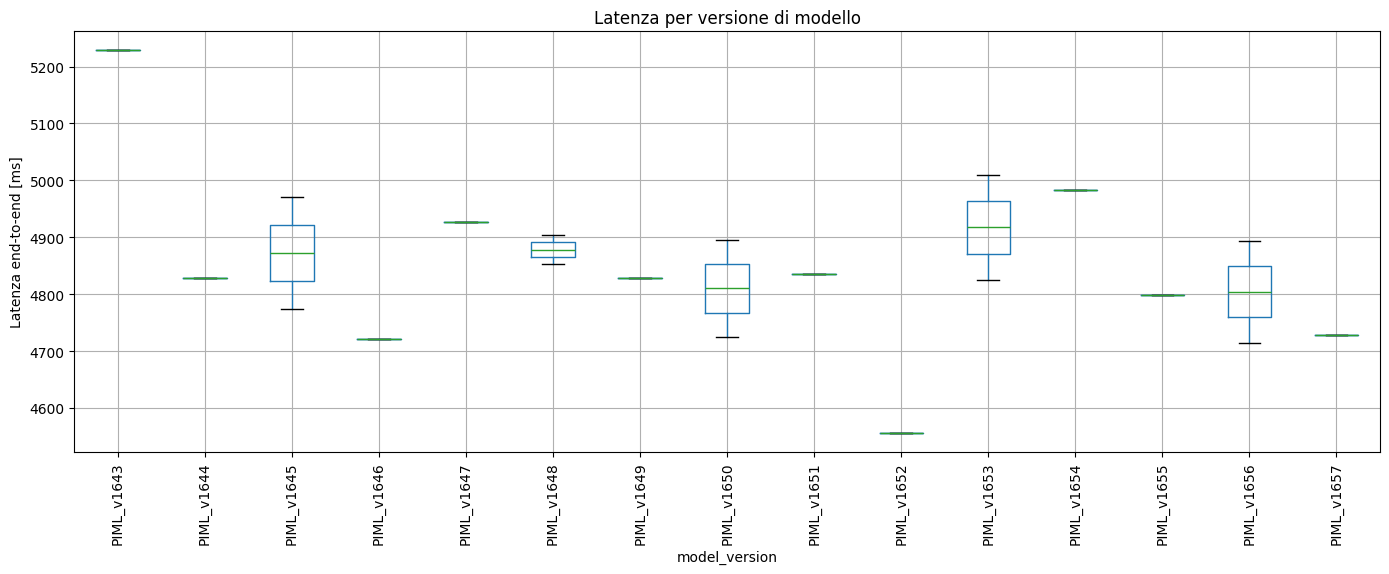

In [7]:
if "model_version" in df_ok.columns:
    print("Distribuzione dei run per model_version:")
    display(df_ok["model_version"].value_counts())

    fig, ax = plt.subplots(figsize=(14, 6))
    df_ok.boxplot(column="e2e_latency_ms", by="model_version", ax=ax)
    plt.xticks(rotation=90)
    ax.set_ylabel("Latenza end-to-end [ms]")
    ax.set_title("Latenza per versione di modello")
    plt.suptitle("")
    plt.tight_layout()
    plt.show()

else:
    print("Colonna 'model_version' non presente nei risultati.")


### Collegamento con monitoring_log.jsonl (mse_free, drift reale)

In [8]:
def load_monitoring_log(path, last_n=None):
    if not os.path.exists(path):
        print(f"File non trovato: {path}")
        return pd.DataFrame()

    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError:
                continue

    if last_n is not None and last_n > 0:
        rows = rows[-last_n:]

    return pd.DataFrame(rows)


mon_df = load_monitoring_log(MONITORING_LOG, last_n=500)

print("Righe nel monitoring_log.jsonl:", len(mon_df))
mon_df.tail()


Righe nel monitoring_log.jsonl: 28


,time,simulation_id,model_version,latency_ms,drift_score,mse_free,stability_index,confidence
23,2025-11-25T20:05:40.641682,STRESS_20251125_200533_016,PIML_v1654,0,0.9360,0.097957,4.0,0.971739
24,2025-11-25T20:05:48.005098,STRESS_20251125_200540_017,PIML_v1655,0,0.1958,0.091795,4.0,0.957998
25,2025-11-25T20:05:55.290699,STRESS_20251125_200548_018,PIML_v1656,0,0.1753,0.092873,4.0,0.945007
26,2025-11-25T20:06:02.749823,STRESS_20251125_200555_019,PIML_v1656,0,0.4366,0.099913,4.0,0.340566
27,2025-11-25T20:06:10.057246,STRESS_20251125_200602_020,PIML_v1657,0,0.6344,0.087208,4.0,0.752990


### Confronto drift e mse_free dal monitoring log

,time,simulation_id,model_version,latency_ms,drift_score,mse_free
18,2025-11-25T20:05:03.600045,STRESS_20251125_200456_011,PIML_v1650,0,0.7168,0.090016
19,2025-11-25T20:05:11.010665,STRESS_20251125_200503_012,PIML_v1651,0,0.7041,0.096461
20,2025-11-25T20:05:18.121841,STRESS_20251125_200511_013,PIML_v1652,0,0.8221,0.084692
21,2025-11-25T20:05:25.510901,STRESS_20251125_200518_014,PIML_v1653,0,0.9836,0.095627
22,2025-11-25T20:05:33.092387,STRESS_20251125_200525_015,PIML_v1653,0,0.5761,0.103681
23,2025-11-25T20:05:40.641682,STRESS_20251125_200533_016,PIML_v1654,0,0.9360,0.097957
24,2025-11-25T20:05:48.005098,STRESS_20251125_200540_017,PIML_v1655,0,0.1958,0.091795
25,2025-11-25T20:05:55.290699,STRESS_20251125_200548_018,PIML_v1656,0,0.1753,0.092873
26,2025-11-25T20:06:02.749823,STRESS_20251125_200555_019,PIML_v1656,0,0.4366,0.099913
27,2025-11-25T20:06:10.057246,STRESS_20251125_200602_020,PIML_v1657,0,0.6344,0.087208


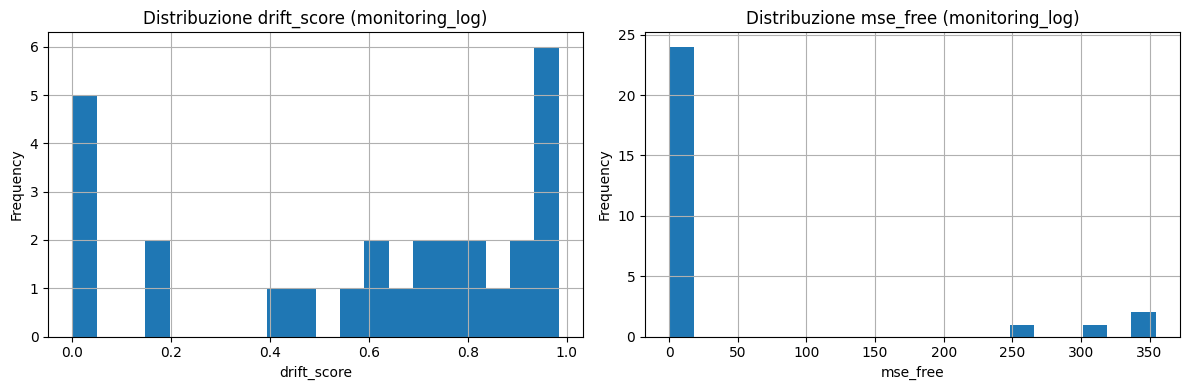

In [9]:
if not mon_df.empty:
    for col in ["latency_ms", "drift_score", "mse_free"]:
        if col in mon_df.columns:
            mon_df[col] = pd.to_numeric(mon_df[col], errors="coerce")

    display(mon_df[["time", "simulation_id", "model_version", "latency_ms", "drift_score", "mse_free"]].tail(10))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    mon_df["drift_score"].dropna().plot(kind="hist", bins=20, ax=axes[0])
    axes[0].set_title("Distribuzione drift_score (monitoring_log)")
    axes[0].set_xlabel("drift_score")

    mon_df["mse_free"].dropna().plot(kind="hist", bins=20, ax=axes[1])
    axes[1].set_title("Distribuzione mse_free (monitoring_log)")
    axes[1].set_xlabel("mse_free")

    plt.tight_layout()
    plt.show()
else:
    print("monitoring_log vuoto o non disponibile.")


### Sintesi numerica per la tesi

In [10]:
summary = {}

if not df_ok.empty:
    summary["n_runs_ok"] = len(df_ok)
    summary["e2e_latency_ms_mean"] = df_ok["e2e_latency_ms"].mean()
    summary["e2e_latency_ms_p95"] = df_ok["e2e_latency_ms"].quantile(0.95)

    if "svc_latency_ms" in df_ok.columns:
        summary["svc_latency_ms_mean"] = df_ok["svc_latency_ms"].mean()

    if "confidence" in df_ok.columns:
        summary["confidence_mean"] = df_ok["confidence"].mean()

summary


{'n_runs_ok': 20,
 'e2e_latency_ms_mean': 4850.061499999999,
 'e2e_latency_ms_p95': 5021.177000000001,
 'svc_latency_ms_mean': 12.342,
 'confidence_mean': 0.7843084052205086}